#  Gradient Descent from Scratch

## 1. Introduction & Why Optimization Matters
Welcome to the ultimate guide to Gradient Descent (GD). This algorithm is the workhorse of Machine Learning and Deep Learning, serving as the primary method for training models by finding the optimal parameters that minimize a given cost function.

In Machine Learning, a model learns by minimizing its errors. **Optimization** is the process of adjusting the model's parameters (weights and biases) to reduce this error. Without optimization, our models would just be making random guesses.

## 2. Loss Functions & Convexity
### Loss Function
A **Loss Function** (or **Cost Function**) quantifies how wrong a model's predictions are compared to the actual data.
1. **MSE (Mean Squared Error)**: Heavily penalizes large errors. Standard for regression.
2. **MAE (Mean Absolute Error)**: Robust to outliers.
3. **Huber Loss**: A combination of MSE and MAE.

### Convex vs Non-convex Functions

- **Convex Functions**: Have a single, global minimum (like a bowl). Linear regression with MSE always yields a convex cost surface.
- **Non-Convex Functions**: Have multiple "valleys" (local minima) and peaks. Deep neural networks typically have highly non-convex cost surfaces, making optimization challenging.

```mermaid
graph LR
    A[Loss Functions] --> B[Convex]
    A --> C[Non-convex]
    
    B --> D[One Global Minimum]
    B --> E[Easy to Optimize]
    B --> F[Guaranteed Convergence]
    
    C --> G[Multiple Local Minima]
    C --> H[Harder to Optimize]
    C --> I[May Get Stuck]
    
    style B fill:#c8e6c9
    style C fill:#ffebee
```

## 3. What is Gradient Descent?

Imagine you are blindfolded at the top of a mountain and need to reach the lowest point in the valley. You feel the slope of the ground under your feet. By taking steps in the direction where the slope descends the steepest, you eventually reach the bottom.

- **The Slope (Gradient)**: The derivative of the loss function tells us the direction of the steepest *ascent*.

- **Why Subtract?**: Because the gradient points up, we must subtract it to move down. 
    - If slope is positive (going uphill), subtract it -> move left (down).
    - If slope is negative (going downhill), subtract a negative -> move right (down).
 
 $$\theta_{new} = \theta_{old} - \text{learning\_rate} \times \text{gradient}$$

## 4. Step-by-Step Intuition & When to Stop
**Update Rule**: $b_{new} = b_{old} - \alpha \cdot \frac{\partial L}{\partial b}$
**When to stop?**
1. **Tolerance/Convergence**: The change in the loss function or parameters between steps becomes infinitesimally small (e.g., < 0.0001). Alternatively, the slope becomes $\approx 0$ (we reached the bottom).
2. **Max Epochs**: We hit a predefined iteration limit to prevent infinite loops.

## 5. Mathematical Derivation

For a simple Linear Regression model $\hat{y} = mx + b$, our MSE loss function $J(m,b)$ is:

$$J(m,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$

Taking the partial derivatives with respect to $m$ and $b$:

$$\frac{\partial J}{\partial b} = -\frac{2}{n} \sum (y_i - mx_i - b)$$

$$\frac{\partial J}{\partial m} = -\frac{2}{n} \sum (y_i - mx_i - b)x_i$$

Update Rules:

$b_{new} = b_{old} - \alpha \times \frac{\partial J}{\partial b}$

$m_{new} = m_{old} - \alpha \times \frac{\partial J}{\partial m}$

(Where $\alpha$ is the learning rate).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import matplotlib.animation as animation
# import warnings warnings.filterwarnin0gs('ignore')


In [8]:
# Generate synthetic 1D data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)
X = X.flatten()

In [9]:
# Benchmark with OLS
reg = LinearRegression().fit(X.reshape(-1, 1), y)
print(f"OLS Slope (m): {reg.coef_[0]:.4f} | Intercept (b): {reg.intercept_:.4f}")

OLS Slope (m): 27.8281 | Intercept (b): -2.2947


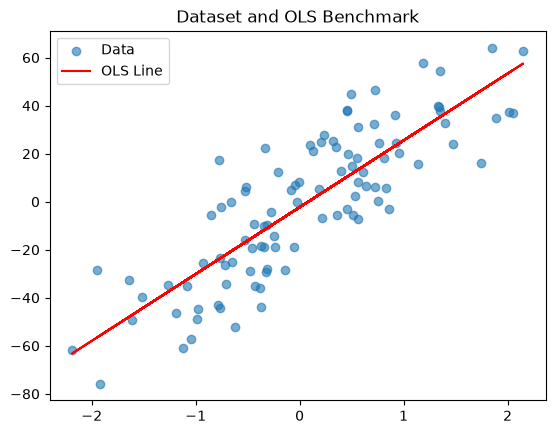

In [10]:
plt.scatter(X, y, alpha=0.6, label='Data')
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red', label='OLS Line')
plt.legend()
plt.title("Dataset and OLS Benchmark")
plt.show()


## 6. Coding GD from Scratch (Intercept Only)
Let's first fix the slope $m$ to the OLS value and only optimize the intercept $b$ to understand the 1D descent.


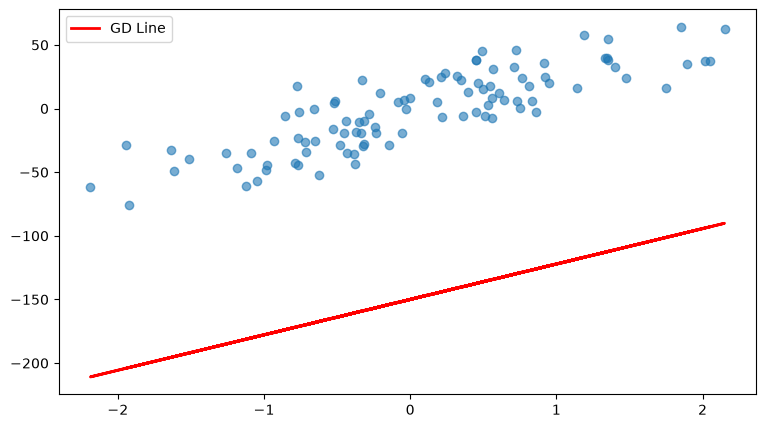

In [11]:
# 1D Gradient Descent (Optimizing 'b' only)
m_fixed = reg.coef_[0]
b_current = -150.0
lr = 0.001
epochs = 30

b_history = [b_current]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X, y, alpha=0.6)
line, = ax.plot(X, m_fixed * X + b_current, color='red', lw=2, label='GD Line')
plt.legend()

def animate_1d(i):
    global b_current
    # Gradient for b
    y_pred = m_fixed * X + b_current
    grad_b = -2 * np.sum(y - y_pred)

    # Update
    b_current = b_current - (lr * grad_b)
    b_history.append(b_current)

    # Plot update
    line.set_ydata(m_fixed * X + b_current)
    ax.set_title(f'Epoch: {i+1} | b: {b_current:.2f}')
    return line,

anim = animation.FuncAnimation(fig, animate_1d, frames=epochs, interval=200, repeat=False)
plt.show()


## 7. Adding Slope (m) & 2D GD
Now we optimize both $m$ and $b$ simultaneously. This requires navigating a 3D loss surface.


In [12]:
class GDRegressor:
    def __init__(self, learning_rate=0.001, epochs=100):
        self.m = 0.0  # Initial random guess
        self.b = 0.0  # Initial random guess
        self.lr = learning_rate
        self.epochs = epochs
        self.m_history = []
        self.b_history = []
        self.loss_history = []

    def fit(self, X, y):
        n = len(X)
        for i in range(self.epochs):
            y_pred = self.m * X + self.b

            # Gradients
            grad_m = -2 * np.sum((y - y_pred) * X) / n
            grad_b = -2 * np.sum(y - y_pred) / n

            # Updates
            self.m -= self.lr * grad_m
            self.b -= self.lr * grad_b

            # Track history
            self.m_history.append(self.m)
            self.b_history.append(self.b)
            self.loss_history.append(np.mean((y - y_pred)**2))

    def predict(self, X):
        return self.m * X + self.b

# Train
gd = GDRegressor(learning_rate=0.01, epochs=100)
gd.fit(X, y)
print(f"Custom GD -> m: {gd.m:.4f}, b: {gd.b:.4f}")


Custom GD -> m: 22.9638, b: -1.4849


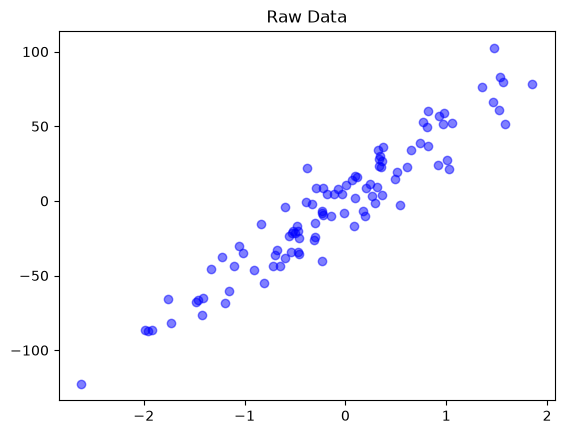

Computed m: 45.7771 | Computed b: 1.7440


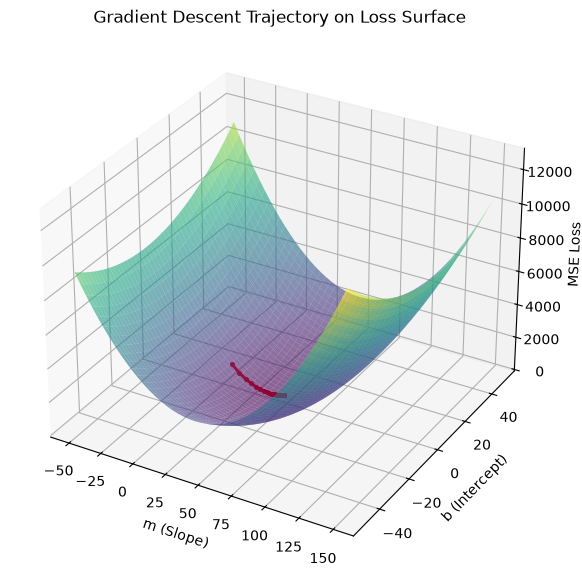

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.datasets import make_regression
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic linear data
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
plt.scatter(X, y, color='blue', alpha=0.5)
plt.title("Raw Data")
plt.show()

class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.m = 0.0 # Initial slope
        self.b = 0.0 # Initial intercept
        self.lr = learning_rate
        self.epochs = epochs
        self.history = {'m': [], 'b': [], 'loss': []}

    def fit(self, X, y):
        n = len(X)
        for i in range(self.epochs):
            # Predictions
            y_pred = self.m * X.ravel() + self.b
            
            # Gradients
            loss_slope_b = (-2/n) * np.sum(y - y_pred)
            loss_slope_m = (-2/n) * np.sum((y - y_pred) * X.ravel())

            # Update parameters
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            
            # Store history
            self.history['m'].append(self.m)
            self.history['b'].append(self.b)
            self.history['loss'].append(np.mean((y - y_pred)**2))
            
        return self

    def predict(self, X):
        return self.m * X.ravel() + self.b

# Train custom model
gd_model = GDRegressor(learning_rate=0.1, epochs=50)
gd_model.fit(X, y)
print(f"Computed m: {gd_model.m:.4f} | Computed b: {gd_model.b:.4f}")

# 3D Loss Surface Visualization
m_range = np.linspace(-50, 150, 50)
b_range = np.linspace(-50, 50, 50)
M, B = np.meshgrid(m_range, b_range)

Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_pred = M[i,j] * X.ravel() + B[i,j]
        Z[i,j] = np.mean((y - y_pred)**2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M, B, Z, cmap='viridis', alpha=0.6)

# Plot descent trajectory
z_history = [np.mean((y - (m * X.ravel() + b))**2) for m, b in zip(gd_model.history['m'], gd_model.history['b'])]
ax.plot3D(gd_model.history['m'], gd_model.history['b'], z_history, 'r.-', markersize=5, linewidth=2)
ax.set_xlabel('m (Slope)')
ax.set_ylabel('b (Intercept)')
ax.set_zlabel('MSE Loss')
plt.title('Gradient Descent Trajectory on Loss Surface')
plt.show()

## 8. Effect of Learning Rate & Initialization
### Effect of Learning Rate ($\alpha$):
- **Too High**: Overshoots the minimum, oscillating or diverging to infinity.
- **Too Low**: Takes forever to converge.
- **Perfect**: Smooth descent to the global minimum.
### Effect of Initialization:
In convex functions (MSE), initialization doesn't matter much (always finds global min). In non-convex functions, bad initialization can trap the model in a local minimum.

## 9. Effect of Loss Function & Data
- **Loss Function**: MSE creates a smooth convex bowl. MAE is not differentiable at 0. Huber loss is robust to outliers.
- **Data Scale**: If features have different scales (e.g., Age: 0-100, Income: 0-100,000), the loss surface becomes an elongated ellipse, causing GD to zig-zag and converge slowly. **Always scale your data!**


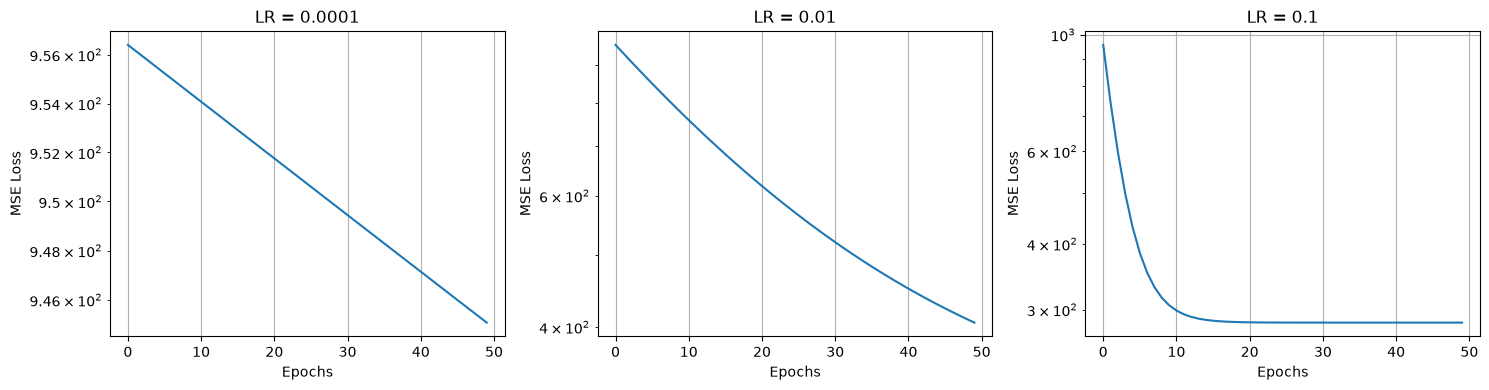

In [13]:
# Visualizing Learning Rate Effects
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lrs = [0.0001, 0.01, 0.1] # 0.5 might diverge for this data

for ax, lr in zip(axes, lrs):
    model = GDRegressor(learning_rate=lr, epochs=50)
    model.fit(X, y)
    ax.plot(model.loss_history)
    ax.set_title(f'LR = {lr}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MSE Loss')
    ax.set_yscale('log')
    ax.grid(True)
plt.tight_layout()
plt.show()

## 10. Interview Questions, Advantages & Limitations
**Interview Questions:**
1. *Why do we subtract the gradient instead of adding it?* (Because gradient points to steepest ascent; we want descent).
2. *What happens if the learning rate is too large?* (Divergence/Overshooting).
3. *Is GD guaranteed to find the global minimum?* (Only for convex functions).

**Advantages:**
- Simple to implement and understand.
- Scales well to high-dimensional spaces.
- Foundation for advanced optimizers (Adam, RMSprop).

**Limitations:**
- Can get stuck in local minima (non-convex).
- Sensitive to feature scaling.
- Computationally slow if using the whole dataset (Batch GD).

**Complexity:**
- **Time**: $O(n \cdot d \cdot E)$ where $n$=samples, $d$=features, $E$=epochs.
- **Space**: $O(d)$ to store weights and gradients.

## 11. Summary Notes & Practice Questions
**Summary:** GD is an iterative first-order optimization algorithm. It uses the derivative of the loss function to step towards the minimum. The learning rate dictates step size.

**Practice Questions:**
1. Implement GD for Logistic Regression (Hint: use Log-Loss and Sigmoid derivative).
2. Add L2 Regularization (Ridge) to the cost function and derive the new gradients.
3. Implement Early Stopping based on a tolerance threshold for the loss change.

---

#  Batch Gradient Descent

## 1. Why Batch Gradient Descent (BGD)?
Earlier, we looked at gradient descent for a single feature ($m$ and $b$). However, modern datasets have hundreds or thousands of features. When you use all $N$ training samples to compute the gradient before updating the weights, it is called **Batch Gradient Descent**. Batch Gradient Descent (BGD) generalizes the math for $n$-dimensions using Matrix operations (Vectorization).
> Batch: Refers to using the entire dataset (all $N$ samples) to compute the gradient before making a single update.

## 2. Mathematical Formulation & Vectorized Derivation
For $n$-dimensional data, using loops is incredibly slow in Python. We use **Matrix Calculus** to vectorize the operations.
Let $\theta$ be the weight vector (including intercept) and $X$ be the feature matrix (with a column of 1s).
$$ J(\theta) = \frac{1}{2N} (y - X\theta)^T (y - X\theta) $$
The gradient is:
$$ \nabla_\theta J(\theta) = -\frac{1}{N} X^T (y - X\theta) $$
**Update Rule**:
$$ \theta_{new} = \theta_{old} - \alpha \left( -\frac{1}{N} X^T (y - X\theta) \right) $$

```mermaid
graph TD
    A[Start] --> B[Initialize Weights θ]
    B --> C[Compute Predictions: ŷ = Xθ]
    C --> D[Compute Error: e = y - ŷ]
    D --> E[Vectorized Gradient: ∇ = -2/N * X^T * e]
    E --> F[Update θ = θ - α * ∇]
    F --> G{Converged?}
    G -->|No| C
    G -->|Yes| H[Return θ]
```

## 3. Algorithm & Complexity
- **Time Complexity**: $O(N \cdot d \cdot E)$ per epoch. Very slow for massive $N$.
- **Space Complexity**: $O(N \cdot d)$ to store the dataset in memory, plus $O(d)$ for weights.
---

#  Batch Gradient Descent

## 1. Why Batch Gradient Descent (BGD)?
In the previous notebook, we calculated the error across the *entire* dataset to take one single step. When you use all $N$ training samples to compute the gradient before updating the weights, it is called **Batch Gradient Descent**.

## 2. Mathematical Formulation & Vectorized Derivation
For $n$-dimensional data, using loops is incredibly slow in Python. We use **Matrix Calculus** to vectorize the operations.
Let $\theta$ be the weight vector (including intercept) and $X$ be the feature matrix (with a column of 1s).
$$ J(\theta) = \frac{1}{2N} (y - X\theta)^T (y - X\theta) $$
The gradient is:
$$ \nabla_\theta J(\theta) = -\frac{1}{N} X^T (y - X\theta) $$
**Update Rule**:
$$ \theta_{new} = \theta_{old} - \alpha \left( -\frac{1}{N} X^T (y - X\theta) \right) $$

```mermaid
graph TD
    A[Start] --> B[Initialize Weights θ]
    B --> C[Compute Predictions: ŷ = Xθ]
    C --> D[Compute Error: e = y - ŷ]
    D --> E[Vectorized Gradient: ∇ = -2/N * X^T * e]
    E --> F[Update θ = θ - α * ∇]
    F --> G{Converged?}
    G -->|No| C
    G -->|Yes| H[Return θ]
```

## 3. Algorithm & Complexity
- **Time Complexity**: $O(N \cdot d \cdot E)$ per epoch. Very slow for massive $N$.
- **Space Complexity**: $O(N \cdot d)$ to store the dataset in memory, plus $O(d)$ for weights.


In [26]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [27]:
# Load Dataset
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [28]:
class BatchGDRegressor:
    def __init__(self, learning_rate=0.01, epochs=1000, tolerance=1e-4):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.coef_ = None
        self.intercept_ = None
        self.loss_history = []

    def fit(self, X, y):
        N, d = X.shape
        self.coef_ = np.ones(d)
        self.intercept_ = 0

        for epoch in range(self.epochs):
            # Vectorized predictions
            y_hat = np.dot(X, self.coef_) + self.intercept_
            error = y - y_hat

            # Vectorized gradients
            grad_intercept = -2 * np.mean(error)
            grad_coef = -2 * np.dot(error, X) / N

            # Update
            self.intercept_ -= self.lr * grad_intercept
            self.coef_ -= self.lr * grad_coef

            # Track loss
            loss = np.mean(error**2)
            self.loss_history.append(loss)

            # Early stopping
            if epoch > 0 and abs(self.loss_history[-2] - loss) < self.tolerance:
                print(f"Converged at epoch {epoch}")
                break

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

# Train
bgd = BatchGDRegressor(learning_rate=0.05, epochs=1000)
bgd.fit(X_train, y_train)
print(f"BGD R2 Score: {r2_score(y_test, bgd.predict(X_test)):.4f}")


BGD R2 Score: 0.3198


## 4. Visualization & Comparison with Sklearn
Let's visualize the smooth convergence of BGD and compare it with Scikit-Learn's analytical solution.


Sklearn R2 Score: 0.4399


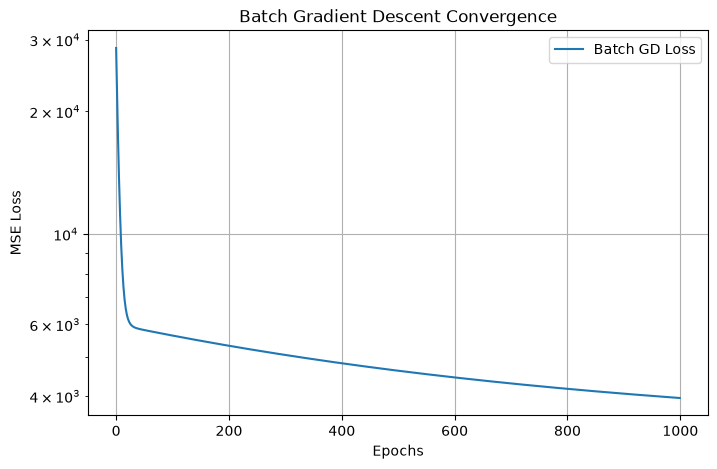

In [15]:
# Comparison with Sklearn
sk_reg = LinearRegression().fit(X_train, y_train)
print(f"Sklearn R2 Score: {r2_score(y_test, sk_reg.predict(X_test)):.4f}")

# Plot Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(bgd.loss_history, label='Batch GD Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent Convergence')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## 5. Pros, Cons & Interview Questions
**Pros:**
- Stable and smooth convergence.
- Guaranteed to find the global minimum for convex functions.
- Easy to implement with vectorized operations.

**Cons:**
- **Extremely slow** for large datasets (must process all $N$ rows per step).
- Requires the entire dataset to fit in RAM.
- Cannot update the model online (streaming data).

**Interview Questions:**
1. *Why is BGD not suitable for deep learning on large datasets?* (Because calculating the gradient over millions of images for a single weight update is computationally prohibitive).
2. *How does BGD handle redundant data?* (It wastes computation on redundant data that provides the same gradient information).
3. *How does Vectorization speed up Batch Gradient Descent?* (It replaces explicit for loops in Python with highly optimized C/C++ backend BLAS (Basic Linear Algebra Subprograms) libraries that parallelize mathematical operations on modern hardware.)

## 6. Exercises
1. Modify the `BatchGDRegressor` to include L2 Regularization (Ridge Regression).
2. Implement Feature Scaling (StandardScaler) and observe how it changes the shape of the loss curve and convergence speed.

---

#  Stochastic Gradient Descent (SGD)

## 1. Why Batch GD becomes Slow & SGD Intuition
As stated, Batch GD calculates the error on the entire dataset to make one step. For large datasets, this is computationally devastating and prohibits "out-of-core" learning (where data doesn't fit in RAM). If you have 10 Million rows, BGD calculates the error for all 10M rows just to take *one tiny step*.
**The Solution**: Stochastic Gradient Descent (SGD). Instead of the whole batch, we randomly pick **one single row**, calculate the gradient, and update the weights immediately.

> Analogy: Instead of polling the entire country to find out public opinion before making a decision (Batch GD), you ask one random person and immediately change your mind based on what they say (SGD).

```mermaid
graph LR
    A[Batch GD] -->|Uses ALL N rows| B(Smooth, slow, memory heavy)
    C[SGD] -->|Uses 1 random row| D(Erratic, lightning fast, memory efficient)
```

## 2. Mathematical Formulation & Noisy Updates
The update happens per sample $(x^{(i)}, y^{(i)})$:
$$ \theta = \theta - \alpha \cdot \nabla J(\theta; x^{(i)}, y^{(i)}) $$
Because we use only one sample, the gradient is a very noisy estimate of the true gradient. The path to the minimum is highly erratic, but it gets *close* to the minimum very quickly.

## 3. Epochs & Online Learning
- **Epoch**: One full pass through the entire dataset. In SGD, we do $N$ updates per epoch.
- **Online Learning**: SGD can update weights as new data arrives in real-time without retraining from scratch.



In [16]:
import time

class SGDRegressorCustom:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        N, d = X.shape
        self.coef_ = np.ones(d)
        self.intercept_ = 0

        for epoch in range(self.epochs):
            # Shuffle data every epoch
            idx = np.random.permutation(N)
            X_shuffled, y_shuffled = X[idx], y[idx]

            for i in range(N):
                xi, yi = X_shuffled[i], y_shuffled[i]

                # Predict for 1 sample
                y_hat = np.dot(xi, self.coef_) + self.intercept_
                error = yi - y_hat

                # Update immediately
                self.intercept_ -= self.lr * (-2 * error)
                self.coef_ -= self.lr * (-2 * error * xi)

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

# Time Comparison
start = time.time()
sgd_custom = SGDRegressorCustom(learning_rate=0.01, epochs=10)
sgd_custom.fit(X_train, y_train)
print(f"Custom SGD Time: {time.time() - start:.4f}s | R2: {r2_score(y_test, sgd_custom.predict(X_test)):.4f}")

start = time.time()
bgd = BatchGDRegressor(learning_rate=0.05, epochs=10)
bgd.fit(X_train, y_train)
print(f"Custom BGD Time: {time.time() - start:.4f}s | R2: {r2_score(y_test, bgd.predict(X_test)):.4f}")

Custom SGD Time: 0.0141s | R2: 0.2370
Custom BGD Time: 0.0000s | R2: -0.6576


## 4. Learning Rate Schedules
Because SGD bounces around the minimum at the end, we use **Learning Schedules** (Simulated Annealing). We start with a high LR to move fast, and gradually reduce it so it "settles" into the minimum.
- **Constant**: $\alpha$ stays the same.
- **Time Decay**: $\alpha = \frac{\alpha_0}{1 + k \cdot t}$
- **Exponential**: $\alpha = \alpha_0 \cdot e^{-kt}$

```mermaid
graph TD
    A[Learning Schedules] --> B[Constant]
    A --> C[Time Decay]
    A --> D[Step Decay]
    A --> E[Exponential]
    A --> F[Inverse Scaling]
    
    B --> G[η = η₀]
    C --> H["η = η₀/(1+kt)"]
    D --> I["η = η₀×0.5^(t/step)"]
    E --> J["η = η₀×e^(-kt)"]
    F --> K["η = η₀/(1+kt²)"]
```

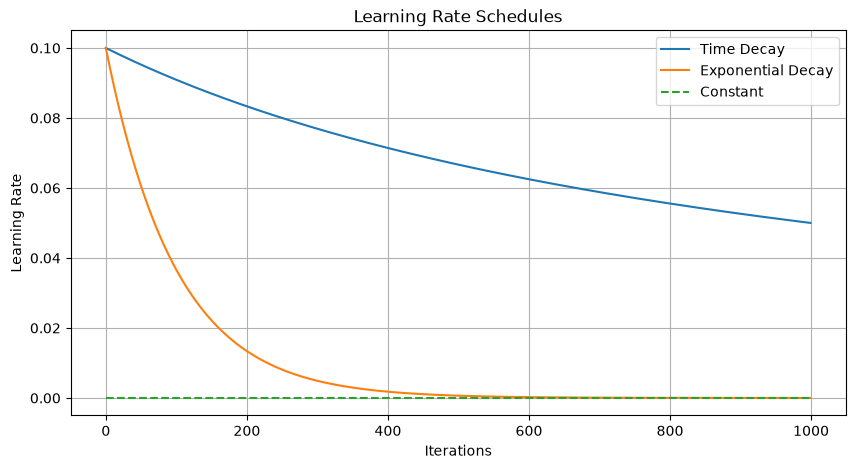

In [17]:
# Visualizing Learning Schedules
t = np.arange(0, 1000)
plt.figure(figsize=(10, 5))
plt.plot(t, 0.1 / (1 + 0.001 * t), label='Time Decay')
plt.plot(t, 0.1 * (0.99 ** t), label='Exponential Decay')
plt.plot(t, np.full_like(t, 0.1), label='Constant', linestyle='--')
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedules')
plt.legend()
plt.grid(True)
plt.show()


## 5. Sklearn SGDRegressor & Practical Tips
Scikit-Learn implements SGD efficiently in C/Cython. Always use `StandardScaler` before SGD, as it is highly sensitive to unscaled features!


In [18]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sklearn SGD with learning schedule
sgd_sk = SGDRegressor(max_iter=100, learning_rate='invscaling', eta0=0.1, random_state=42)
sgd_sk.fit(X_train_scaled, y_train)
print(f"Sklearn SGD R2: {r2_score(y_test, sgd_sk.predict(X_test_scaled)):.4f}")


Sklearn SGD R2: 0.4346


## 6. Advantages, Limitations & Interview Questions
**When to use SGD?**
- Massive datasets (Millions of rows).
- Out-of-core learning (data doesn't fit in RAM).
- Real-time streaming data.
```mermaid
graph TD
    A[Use SGD When] --> B[Large Dataset > 1M]
    A --> C[Need Fast Training]
    A --> D[Online Learning]
    A --> E[Limited Memory]
    A --> F[Escaping Local Minima]
    
    B --> G[Memory Efficient]
    C --> H[Real-time Updates]
    D --> I[Streaming Data]
    E --> J[One Sample at a Time]
    F --> K[Randomness Helps]
```

**Limitations:**
- Requires feature scaling.
- Never truly converges (keeps bouncing).
- Harder to tune due to noise.

**Interview Questions:**
1. *What is the difference between an Epoch and an Iteration in SGD?* (1 Iteration = 1 sample update. 1 Epoch = N iterations).
2. *Why does SGD require learning rate decay?* (To prevent it from bouncing out of the global minimum at the end of training).
3. *Can SGD escape local minima better than Batch GD?* (Yes! Because of its noisy, erratic updates based on single samples, SGD can often "bounce" out of shallow local minima that would otherwise trap the smooth trajectory of Batch GD.)
```mermaid
graph TD
    A[SGD Terminology] --> B[Epoch]
    A --> C[Iteration]
    A --> D[Batch]
    
    B --> E[One pass through all data]
    C --> F[One update step]
    D --> G[Set of samples]
    
    E --> H[epochs × m iterations]
```
---

#  Mini-Batch Gradient Descent

## 1. Why Mini-Batch Gradient Descent (MBGD)?
- **BGD** is too slow (processes all $N$ rows).
- **SGD** is too erratic and loses the speed benefits of hardware vectorization (GPUs love matrix math, but SGD only feeds it 1D vectors).
- **MBGD** is the ultimate compromise. We select a random "mini-batch" (e.g., 32, 64, 128 rows), calculate the gradient, and update. It provides a stable path while remaining computationally efficient. **This is the standard algorithm used in Deep Learning.**

```mermaid
graph TD
    subgraph Variants Comparison
        A[Batch GD] -->|All Samples| B(Stable but Slow)
        C[Stochastic GD] -->|1 Sample| D(Fast but Erratic)
        E[Mini-Batch GD] -->|32-128 Samples| F(Fast & Stable)
    end
    
    style E fill:#d4edda,stroke:#28a745,stroke-width:2px
    style F fill:#d4edda,stroke:#28a745,stroke-width:2px
```

## 2. Mathematical Derivation & GPU Optimization
For a batch $B$ of size $k$:
$$ \theta = \theta - \alpha \frac{1}{k} \sum_{j=1}^k \nabla J(\theta; x^{(i_j)}, y^{(i_j)}) $$
**GPU Optimization**: By grouping data into matrices of size $k \times d$, we can leverage highly optimized BLAS (Basic Linear Algebra Subprograms) and GPU parallelism, making MBGD exponentially faster than SGD in practice.


In [19]:
class MBGDRegressor:
    def __init__(self, batch_size=32, learning_rate=0.01, epochs=100):
        self.batch_size = batch_size
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None
        self.loss_history = []

    def fit(self, X, y):
        N, d = X.shape
        self.coef_ = np.ones(d)
        self.intercept_ = 0

        for epoch in range(self.epochs):
            # Shuffle data
            indices = np.random.permutation(N)
            X_shuffled, y_shuffled = X[indices], y[indices]

            epoch_loss = 0
            num_batches = 0

            # Process in chunks
            for i in range(0, N, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                k = X_batch.shape[0]

                # Vectorized predictions for the batch
                y_hat = np.dot(X_batch, self.coef_) + self.intercept_
                error = y_batch - y_hat

                # Vectorized gradients
                grad_intercept = -2 * np.mean(error)
                grad_coef = -2 * np.dot(error, X_batch) / k

                # Update
                self.intercept_ -= self.lr * grad_intercept
                self.coef_ -= self.lr * grad_coef

                epoch_loss += np.mean(error**2)
                num_batches += 1

            self.loss_history.append(epoch_loss / num_batches)

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

# Train MBGD
mbgd = MBGDRegressor(batch_size=32, learning_rate=0.01, epochs=100)
mbgd.fit(X_train, y_train)
print(f"MBGD R2 Score: {r2_score(y_test, mbgd.predict(X_test)):.4f}")

MBGD R2 Score: 0.1226


## 3. Animation & Comparison
Let's visualize how the three algorithms navigate the loss landscape.


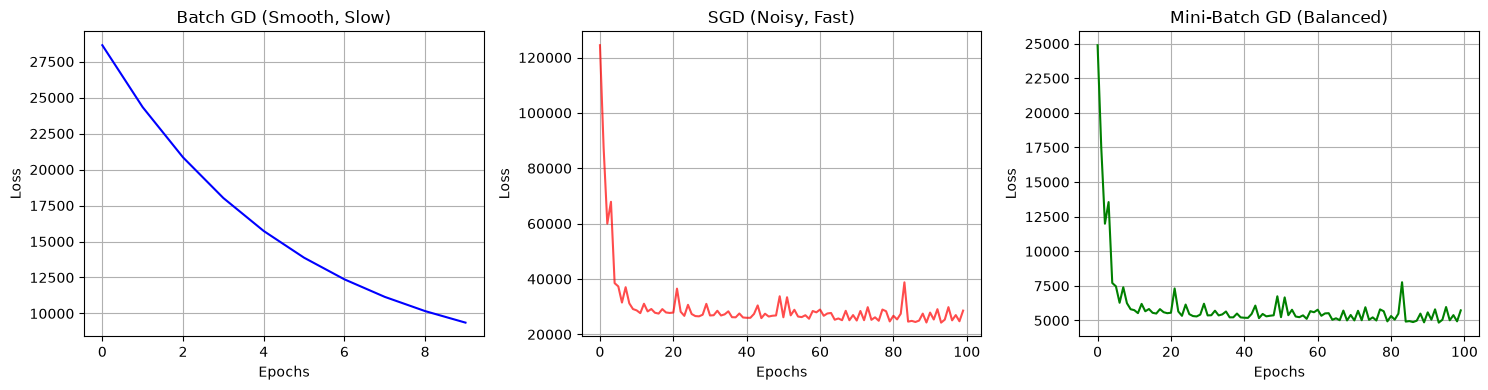

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# We will simulate the loss curves for comparison
# (Assuming we tracked batch losses for SGD/MBGD)
axes[0].plot(bgd.loss_history[:100], label='BGD', color='blue')
axes[0].set_title('Batch GD (Smooth, Slow)')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

# Fix: Ensure noise array matches the length of the history being used
history_len = len(mbgd.loss_history)
sgd_losses = np.array(mbgd.loss_history) * 5 + np.random.normal(0, 50, history_len)

axes[1].plot(sgd_losses[:100], label='SGD', color='red', alpha=0.7)
axes[1].set_title('SGD (Noisy, Fast)')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss'); axes[1].grid(True)

axes[2].plot(mbgd.loss_history[:100], label='MBGD', color='green')
axes[2].set_title('Mini-Batch GD (Balanced)')
axes[2].set_xlabel('Epochs'); axes[2].set_ylabel('Loss'); axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Performance Benchmarking & Choosing Batch Size
How do we choose the batch size?
- **Batch Size = 1**: Pure SGD. Fast updates, very noisy.
- **Batch Size = N**: Pure BGD. Slow updates, exact gradient.
- **Batch Size = 32 to 256**: The "Sweet Spot" for most Deep Learning and ML tasks. Maximizes GPU utilization without losing too much stochasticity (which helps escape local minima).
> **Recommendation**: Start with 32. It provides a good empirical balance between gradient estimation accuracy and computational speed. If training is too slow and your hardware can handle it, increase to 64 or 128.

```mermaid
graph TD
    A[Batch Size Factors] --> B[Memory]
    A --> C[GPU Architecture]
    A --> D[Convergence]
    
    B --> E[RAM/VRAM Limits]
    C --> F[Power of 2]
    D --> G[Stable Updates]
    
    F --> H[GPU Optimized]
    H --> I[32, 64, 128, 256]
```

```mermaid
graph TD
    A[Batch Size Selection] --> B[Small Batch]
    A --> C[Medium Batch]
    A --> D[Large Batch]
    
    B --> E[< 32]
    B --> F[More Noise]
    B --> G[Better Generalization]
    
    C --> H[32 - 256]
    C --> I[Balanced]
    C --> J[Recommended]
    
    D --> K[> 512]
    D --> L[Less Noise]
    D --> M[Less Generalization]
```


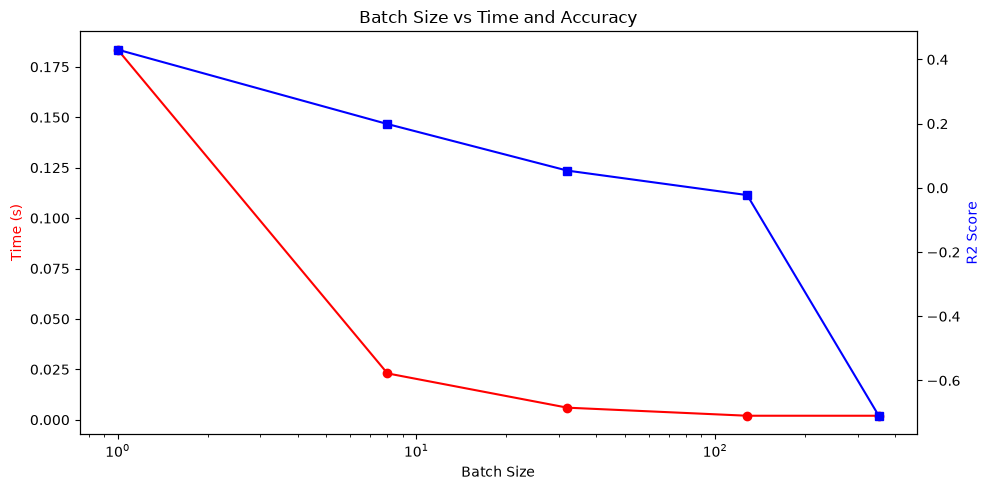

In [21]:
# Benchmarking Batch Sizes
batch_sizes = [1, 8, 32, 128, X_train.shape[0]] # 1=SGD, N=BGD
times = []
scores = []

for bs in batch_sizes:
    start = time.time()
    model = MBGDRegressor(batch_size=bs, learning_rate=0.01, epochs=50)
    model.fit(X_train, y_train)
    times.append(time.time() - start)
    scores.append(r2_score(y_test, model.predict(X_test)))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(batch_sizes, times, 'o-', color='red', label='Training Time (s)')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Time (s)', color='red')
ax1.set_xscale('log')

ax2 = ax1.twinx()
ax2.plot(batch_sizes, scores, 's-', color='blue', label='R2 Score')
ax2.set_ylabel('R2 Score', color='blue')

plt.title('Batch Size vs Time and Accuracy')
fig.tight_layout()
plt.show()


## 5. Practical Recommendations & Interview Questions
**Recommendations:**
1. Always shuffle your data before creating batches.
2. Use powers of 2 for batch sizes (32, 64, 128, 256) to optimize memory alignment in hardware.
3. Implement Learning Rate Decay when using MBGD to ensure convergence.

**Interview Questions:**
1. *Why is Mini-Batch GD the default in Deep Learning frameworks like PyTorch/TensorFlow?* (It balances the vectorization speed of hardware with the regularization effect of noise).
2. *How does batch size affect the generalization of the model?* (Smaller batches introduce noise that acts as a regularizer, often leading to better generalization on test data, a phenomenon known as the "generalization gap").
3. *What is the space complexity of MBGD?* (It requires loading the batch into memory, so $O(\text{batch\_size} \times d)$, which is much smaller than BGD's $O(N \times d)$).
4. *Why don't we just use the largest batch size that fits in GPU memory?* (Surprisingly, extremely large batch sizes often generalize worse on unseen data. The slight "noise" introduced by smaller mini-batches (like 32) acts as a form of implicit regularization, preventing the model from overfitting to sharp, narrow local minima in the loss landscape.)

```mermaid
graph TD
    A[Gradient Descent Variants] --> B[Batch GD]
    A --> C[Stochastic GD]
    A --> D[Mini-Batch GD]
    
    B --> E[Uses ALL data]
    C --> F[Uses 1 sample]
    D --> G[Uses subset]
    
    E --> H[Accurate, Slow]
    F --> I[Fast, Noisy]
    G --> J[Balanced]
```